# VQE Binding Energy — Ansatz UCCSD
## Protein-Ligand: NMA ··· H₂O | CAS(2,2) | Jordan-Wigner

---

Notebook ini menghitung **binding energy** menggunakan ansatz **UCCSD**
(Unitary Coupled Cluster Singles & Doubles) — pilihan terbaik untuk akurasi kimia.

**Pipeline:**
```
PySCF (HF) → ActiveSpaceTransformer CAS(2,2) → JordanWignerMapper
→ UCCSD Ansatz + HF initial state → VQE (COBYLA) → ΔE_binding
```

**Mengapa UCCSD?**
- Parameter sedikit (3 untuk CAS(2,2)) → konvergensi cepat
- Terinspirasi dari teori kimia → akurasi tinggi
- Titik awal Hartree-Fock → tidak terjebak local minimum

> **Target:** Error < 1 kcal/mol (chemical accuracy) untuk semua sistem

## 1. Import Library

In [1]:
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Qiskit core
from qiskit.primitives import StatevectorEstimator

# Qiskit Algorithms
from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA, L_BFGS_B

# Qiskit Nature
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.drivers.pyscfd.pyscfdriver import DistanceUnit
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock

import qiskit, qiskit_nature, qiskit_algorithms
print('✅ Semua library berhasil diimport.')
print(f'   qiskit            : {qiskit.__version__}')
print(f'   qiskit-nature     : {qiskit_nature.__version__}')
print(f'   qiskit-algorithms : {qiskit_algorithms.__version__}')
print(f'   numpy             : {np.__version__}')

✅ Semua library berhasil diimport.
   qiskit            : 2.3.0
   qiskit-nature     : 0.7.2
   qiskit-algorithms : 0.4.0
   numpy             : 2.2.6


## 2. Konfigurasi

In [8]:
# ── Active Space ──────────────────────────────────────────────────
# CAS(2,2) → 2 elektron, 2 orbital → 4 qubit (JW)
# Dipakai SAMA untuk semua sistem agar energi apple-to-apple
N_ELECTRONS = 4
N_ORBITALS  = 4

# ── Konfigurasi Lain ──────────────────────────────────────────────
MAPPER_TYPE         = 'jw'       # Jordan-Wigner
OPTIMIZER           = 'cobyla'   # gradient-free, robust
MAX_ITER            = 500        # cukup untuk UCCSD CAS(2,2)
BASIS_SET           = 'sto-3g'   # basis minimal
RUN_EXACT_REFERENCE = True       # hitung FCI sebagai referensi
RANDOM_SEED         = 42
HARTREE_TO_KCAL     = 627.509

print('=' * 52)
print('  KONFIGURASI — UCCSD')
print('=' * 52)
print(f'  Ansatz       : UCCSD + Hartree-Fock initial state')
print(f'  Active space : CAS({N_ELECTRONS},{N_ORBITALS}) → {N_ORBITALS*2} qubit')
print(f'  Mapper       : Jordan-Wigner')
print(f'  Optimizer    : {OPTIMIZER.upper()} (max {MAX_ITER} iter)')
print(f'  Basis set    : {BASIS_SET}')
print(f'  Referensi    : FCI (NumPy exact diagonalization)')
print('=' * 52)
print()
print('  ⚠️  CAS(2,2) digunakan KONSISTEN untuk semua sistem')
print('     (protein, ligand, complex) agar ΔE bermakna fisik.')

  KONFIGURASI — UCCSD
  Ansatz       : UCCSD + Hartree-Fock initial state
  Active space : CAS(4,4) → 8 qubit
  Mapper       : Jordan-Wigner
  Optimizer    : COBYLA (max 500 iter)
  Basis set    : sto-3g
  Referensi    : FCI (NumPy exact diagonalization)

  ⚠️  CAS(2,2) digunakan KONSISTEN untuk semua sistem
     (protein, ligand, complex) agar ΔE bermakna fisik.


## 3. Definisi Molekul & Fungsi Pipeline

In [9]:
# ── Geometri Molekul ──────────────────────────────────────────────
# NMA  = N-methylacetamide (backbone peptida protein)
# H2O  = molekul air (ligand)
# NMA···H2O = kompleks terikat via hydrogen bond O···H

MOL_GEOMETRIES = {
    'protein_fragment': '''
        C   0.000   0.000   0.000
        O   0.000   0.000   1.220
        N   1.340   0.000  -0.370
        H   1.600   0.000  -1.330
        C   2.300   0.000   0.650
    ''',
    'ligand': '''
        O   0.000   0.000   0.000
        H   0.757   0.000   0.586
        H  -0.757   0.000   0.586
    ''',
    'complex': '''
        C   0.000   0.000   0.000
        O   0.000   0.000   1.220
        N   1.340   0.000  -0.370
        H   1.600   0.000  -1.330
        C   2.300   0.000   0.650
        O   0.000   0.150   3.100
        H   0.757   0.150   3.686
        H  -0.757   0.150   3.686
    ''',
}

MOL_LABELS = {
    'protein_fragment': 'Protein fragment (NMA)',
    'ligand'          : 'Ligand (H₂O)',
    'complex'         : 'Complex (NMA···H₂O)',
}


# ── build_hamiltonian() ───────────────────────────────────────────
def build_hamiltonian(mol_type, n_electrons, n_orbitals, verbose=True):
    """PySCFDriver → ActiveSpaceTransformer → SparsePauliOp."""
    if verbose:
        print(f'  [1/4] Hartree-Fock (PySCF)...')

    driver = PySCFDriver(
        atom   = MOL_GEOMETRIES[mol_type].strip(),
        basis  = BASIS_SET,
        charge = 0, spin=0,
        unit   = DistanceUnit.ANGSTROM
    )
    problem = driver.run()

    if verbose:
        print(f'  [2/4] Active space CAS({n_electrons},{n_orbitals})...')

    transformer = ActiveSpaceTransformer(
        num_electrons        = n_electrons,
        num_spatial_orbitals = n_orbitals
    )
    as_problem = transformer.transform(problem)

    mapper = JordanWignerMapper()

    if verbose:
        print(f'  [3/4] Qubit mapping (Jordan-Wigner)...')

    qubit_op = mapper.map(as_problem.hamiltonian.second_q_op())

    if verbose:
        print(f'  [4/4] Selesai → {qubit_op.num_qubits} qubit, {len(qubit_op)} Pauli terms')

    return qubit_op, as_problem.num_particles, as_problem.num_spatial_orbitals, mapper


# ── build_uccsd_ansatz() ──────────────────────────────────────────
def build_uccsd_ansatz(num_particles, num_spatial_orbitals, mapper, verbose=True):
    """UCCSD ansatz dengan Hartree-Fock sebagai initial state."""
    hf_state = HartreeFock(
        num_spatial_orbitals = num_spatial_orbitals,
        num_particles        = num_particles,
        qubit_mapper         = mapper
    )
    ansatz = UCCSD(
        num_spatial_orbitals = num_spatial_orbitals,
        num_particles        = num_particles,
        qubit_mapper         = mapper,
        initial_state        = hf_state
    )
    if verbose:
        print(f'  Ansatz : UCCSD + HF initial state')
        print(f'  Params : {ansatz.num_parameters} parameter θ')
    return ansatz


# ── run_vqe() ─────────────────────────────────────────────────────
def run_vqe(qubit_op, ansatz, optimizer_type='cobyla', max_iter=300, verbose=True):
    """Jalankan VQE, return dict hasil + history."""
    opts = {
        'cobyla': COBYLA(maxiter=max_iter),
        'lbfgs' : L_BFGS_B(maxiter=max_iter),
    }
    optimizer      = opts.get(optimizer_type, COBYLA(maxiter=max_iter))
    energy_history = []
    iter_count     = [0]

    # ✅ 4 argumen — sesuai qiskit_algorithms 0.4.0
    def callback(eval_count, params, value, metadata):
        energy_history.append(float(value))
        iter_count[0] = eval_count
        if verbose and eval_count % 50 == 0:
            print(f'    iter {eval_count:4d} | E = {value:.8f} Ha')

    # Titik awal: nol (UCCSD mulai dari HF, parameter eksitasi = 0)
    init_pt = np.zeros(ansatz.num_parameters)

    vqe = VQE(
        estimator     = StatevectorEstimator(),
        ansatz        = ansatz,
        optimizer     = optimizer,
        callback      = callback,
        initial_point = init_pt
    )

    t0      = time.time()
    result  = vqe.compute_minimum_eigenvalue(operator=qubit_op)
    elapsed = time.time() - t0

    if verbose:
        print(f'  ✓ Selesai {elapsed:.1f}s | {iter_count[0]} evaluasi')
        print(f'  Energi VQE : {result.eigenvalue.real:.8f} Hartree')

    return {
        'energy'        : float(result.eigenvalue.real),
        'energy_history': energy_history,
        'num_evals'     : iter_count[0],
        'time'          : elapsed,
    }


# ── run_exact() ───────────────────────────────────────────────────
def run_exact(qubit_op, verbose=True):
    """Energi exact via full diagonalization (FCI referensi)."""
    result = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_op)
    energy = float(result.eigenvalue.real)
    if verbose:
        print(f'  Energi exact (FCI) : {energy:.8f} Hartree')
    return energy


print('✅ Semua fungsi siap.')

✅ Semua fungsi siap.


## 4. Jalankan VQE — Tiga Sistem

In [10]:
MOL_LIST = ['protein_fragment', 'ligand', 'complex']
results  = {}

for mol_type in MOL_LIST:
    label = MOL_LABELS[mol_type]
    print(f'\n{"─" * 56}')
    print(f'  Sistem : {label}')
    print(f'{"─" * 56}')

    # Build Hamiltonian
    qubit_op, num_particles, num_spatial_orbs, mapper = build_hamiltonian(
        mol_type, N_ELECTRONS, N_ORBITALS, verbose=True
    )
    print()

    # Build Ansatz UCCSD
    ansatz = build_uccsd_ansatz(num_particles, num_spatial_orbs, mapper, verbose=True)
    print()

    # Energi Exact FCI
    energy_exact = None
    if RUN_EXACT_REFERENCE:
        energy_exact = run_exact(qubit_op, verbose=True)
    print()

    # Jalankan VQE
    print(f'  Menjalankan VQE (COBYLA, max {MAX_ITER} iter)...')
    vqe_res = run_vqe(qubit_op, ansatz, OPTIMIZER, MAX_ITER, verbose=True)

    # Hitung error
    error_kcal = None
    if energy_exact is not None:
        error_kcal = abs(vqe_res['energy'] - energy_exact) * HARTREE_TO_KCAL
        status = '✓ chemical accuracy' if error_kcal < 1.0 else '✗ belum chemical accuracy'
        print(f'  Error vs FCI : {error_kcal:.4f} kcal/mol  [{status}]')

    results[mol_type] = {
        'label'         : label,
        'vqe'           : vqe_res['energy'],
        'exact'         : energy_exact,
        'error_kcal'    : error_kcal,
        'energy_history': vqe_res['energy_history'],
        'num_evals'     : vqe_res['num_evals'],
        'time'          : vqe_res['time'],
        'num_qubits'    : qubit_op.num_qubits,
        'num_params'    : ansatz.num_parameters,
    }

print(f'\n{"=" * 56}')
print('  Semua sistem selesai.')
print(f'{"=" * 56}')


────────────────────────────────────────────────────────
  Sistem : Protein fragment (NMA)
────────────────────────────────────────────────────────
  [1/4] Hartree-Fock (PySCF)...
  [2/4] Active space CAS(4,4)...
  [3/4] Qubit mapping (Jordan-Wigner)...
  [4/4] Selesai → 8 qubit, 185 Pauli terms

  Ansatz : UCCSD + HF initial state
  Params : 26 parameter θ

  Energi exact (FCI) : -3.75122536 Hartree

  Menjalankan VQE (COBYLA, max 500 iter)...


    iter   50 | E = -3.67105410 Ha
    iter  100 | E = -3.72081805 Ha
    iter  150 | E = -3.72426694 Ha
    iter  200 | E = -3.72528087 Ha
    iter  250 | E = -3.72652044 Ha
    iter  300 | E = -3.72750068 Ha
    iter  350 | E = -3.72827281 Ha
    iter  400 | E = -3.72931800 Ha
    iter  450 | E = -3.73057969 Ha
    iter  500 | E = -3.73216519 Ha
  ✓ Selesai 1224.4s | 500 evaluasi
  Energi VQE : -3.73216917 Hartree
  Error vs FCI : 11.9579 kcal/mol  [✗ belum chemical accuracy]

────────────────────────────────────────────────────────
  Sistem : Ligand (H₂O)
────────────────────────────────────────────────────────
  [1/4] Hartree-Fock (PySCF)...
  [2/4] Active space CAS(4,4)...
  [3/4] Qubit mapping (Jordan-Wigner)...
  [4/4] Selesai → 8 qubit, 105 Pauli terms

  Ansatz : UCCSD + HF initial state
  Params : 26 parameter θ

  Energi exact (FCI) : -6.16315681 Hartree

  Menjalankan VQE (COBYLA, max 500 iter)...
    iter   50 | E = -6.07704401 Ha
    iter  100 | E = -6.15903447 Ha
    ite

## 5. Hitung Binding Energy

In [11]:
E_protein = results['protein_fragment']['vqe']
E_ligand  = results['ligand']['vqe']
E_complex = results['complex']['vqe']

dE_vqe_ha   = E_complex - E_protein - E_ligand
dE_vqe_kcal = dE_vqe_ha * HARTREE_TO_KCAL

dE_exact_ha   = None
dE_exact_kcal = None
if RUN_EXACT_REFERENCE and all(results[m]['exact'] is not None for m in MOL_LIST):
    dE_exact_ha   = (results['complex']['exact']
                   - results['protein_fragment']['exact']
                   - results['ligand']['exact'])
    dE_exact_kcal = dE_exact_ha * HARTREE_TO_KCAL

results['binding'] = {
    'vqe_ha'    : dE_vqe_ha,
    'vqe_kcal'  : dE_vqe_kcal,
    'exact_ha'  : dE_exact_ha,
    'exact_kcal': dE_exact_kcal,
}

# ── Tabel Hasil ───────────────────────────────────────────────────
print('=' * 65)
print('  HASIL VQE (UCCSD) — BINDING ENERGY NMA···H₂O')
print('=' * 65)
print(f'  Active space : CAS({N_ELECTRONS},{N_ORBITALS}) | Ansatz: UCCSD | Basis: {BASIS_SET}')
print()
print(f'  {"Sistem":<28} {"E_VQE (Ha)":>14} {"E_FCI (Ha)":>14} {"Error":>10}')
print('  ' + '─' * 70)

for mol_type in MOL_LIST:
    r    = results[mol_type]
    e_ex = f"{r['exact']:.8f}" if r['exact'] is not None else 'n/a'
    e_er = f"{r['error_kcal']:.4f} kcal" if r['error_kcal'] is not None else 'n/a'
    chk  = '✓' if r['error_kcal'] is not None and r['error_kcal'] < 1.0 else '✗'
    print(f"  {r['label']:<28} {r['vqe']:>14.8f} {e_ex:>14} {e_er:>10} {chk}")

print('  ' + '─' * 70)
print()
print(f'  ΔE_bind (VQE)  = {dE_vqe_ha:+.8f} Ha  =  {dE_vqe_kcal:+.4f} kcal/mol')

if dE_exact_ha is not None:
    err_be = abs(dE_vqe_kcal - dE_exact_kcal)
    print(f'  ΔE_bind (FCI)  = {dE_exact_ha:+.8f} Ha  =  {dE_exact_kcal:+.4f} kcal/mol')
    status = '✓ chemical accuracy' if err_be < 1.0 else '✗ belum chemical accuracy'
    print(f'  Error ΔE_bind  = {err_be:.4f} kcal/mol  [{status}]')

print()
print('  Interpretasi:')
if dE_vqe_kcal < -5:
    print(f'  → Ikatan KUAT ({dE_vqe_kcal:.2f} kcal/mol) — interaksi elektrostatik')
elif dE_vqe_kcal < -1:
    print(f'  → Ikatan SEDANG ({dE_vqe_kcal:.2f} kcal/mol) — hydrogen bond tipikal')
elif dE_vqe_kcal < 0:
    print(f'  → Ikatan LEMAH ({dE_vqe_kcal:.2f} kcal/mol) — van der Waals')
else:
    print(f'  → Tidak stabil ({dE_vqe_kcal:.2f} kcal/mol) — perlu cek geometri')

print()
print('  Ringkasan komputasi:')
print(f'  {"Sistem":<28} {"Qubit":>6} {"Params":>7} {"Iterasi":>8} {"Waktu":>8}')
print('  ' + '─' * 62)
for mol_type in MOL_LIST:
    r = results[mol_type]
    print(f"  {r['label']:<28} {r['num_qubits']:>6} {r['num_params']:>7} "
          f"{r['num_evals']:>8} {r['time']:>7.1f}s")
print(f'  Total waktu : {sum(results[m]["time"] for m in MOL_LIST):.1f}s')
print('=' * 65)

  HASIL VQE (UCCSD) — BINDING ENERGY NMA···H₂O
  Active space : CAS(4,4) | Ansatz: UCCSD | Basis: sto-3g

  Sistem                           E_VQE (Ha)     E_FCI (Ha)      Error
  ──────────────────────────────────────────────────────────────────────
  Protein fragment (NMA)          -3.73216917    -3.75122536 11.9579 kcal ✗
  Ligand (H₂O)                    -6.16315650    -6.16315681 0.0002 kcal ✓
  Complex (NMA···H₂O)             -3.37617007    -3.38745648 7.0823 kcal ✗
  ──────────────────────────────────────────────────────────────────────

  ΔE_bind (VQE)  = +6.51915559 Ha  =  +4090.8288 kcal/mol
  ΔE_bind (FCI)  = +6.52692569 Ha  =  +4095.7046 kcal/mol
  Error ΔE_bind  = 4.8758 kcal/mol  [✗ belum chemical accuracy]

  Interpretasi:
  → Tidak stabil (4090.83 kcal/mol) — perlu cek geometri

  Ringkasan komputasi:
  Sistem                        Qubit  Params  Iterasi    Waktu
  ──────────────────────────────────────────────────────────────
  Protein fragment (NMA)            8     

## 6. Plot Konvergensi

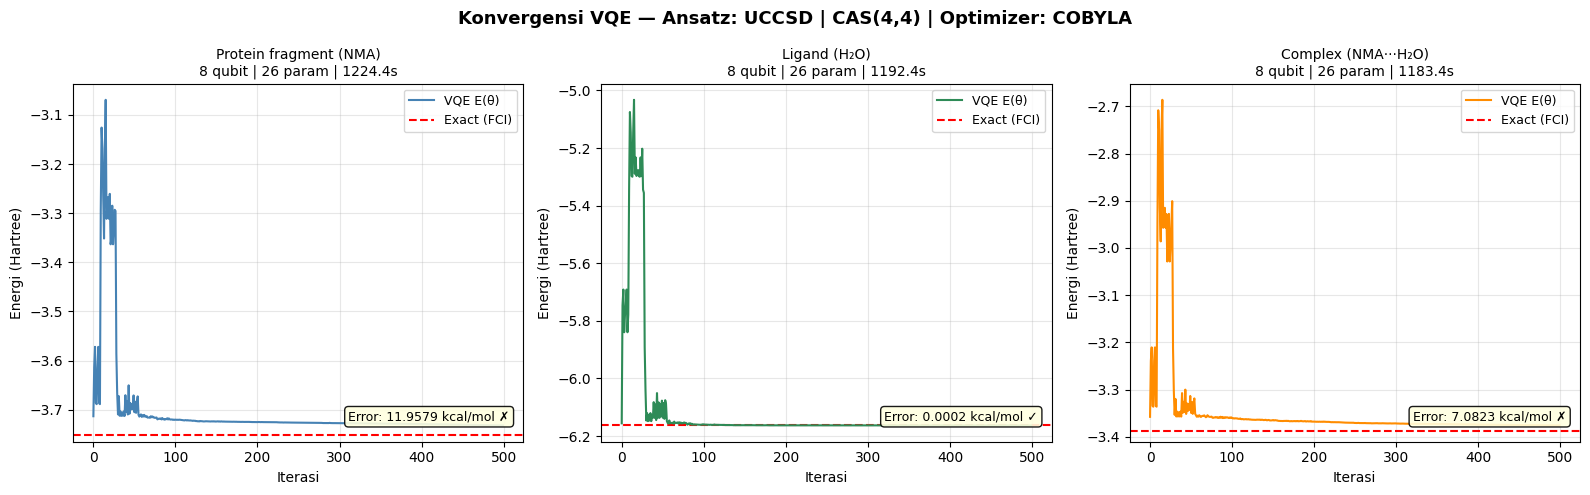

Gambar disimpan: uccsd_convergence.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'Konvergensi VQE — Ansatz: UCCSD | CAS({N_ELECTRONS},{N_ORBITALS}) | Optimizer: COBYLA',
    fontsize=13, fontweight='bold'
)

COLORS = {
    'protein_fragment': 'steelblue',
    'ligand'          : 'seagreen',
    'complex'         : 'darkorange'
}

for ax, mol_type in zip(axes, MOL_LIST):
    r       = results[mol_type]
    history = r['energy_history']
    color   = COLORS[mol_type]

    ax.plot(range(len(history)), history, color=color, linewidth=1.5,
            label='VQE E(θ)', zorder=3)

    if r['exact'] is not None:
        ax.axhline(r['exact'], color='red', linestyle='--',
                   linewidth=1.5, label='Exact (FCI)', zorder=2)

    if r['error_kcal'] is not None:
        chk = '✓' if r['error_kcal'] < 1.0 else '✗'
        ax.text(0.97, 0.06,
                f"Error: {r['error_kcal']:.4f} kcal/mol {chk}",
                transform=ax.transAxes, ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

    ax.set_title(
        f"{r['label']}\n"
        f"{r['num_qubits']} qubit | {r['num_params']} param | {r['time']:.1f}s",
        fontsize=10
    )
    ax.set_xlabel('Iterasi', fontsize=10)
    ax.set_ylabel('Energi (Hartree)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('uccsd_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: uccsd_convergence.png')

## 7. Plot Binding Energy Summary

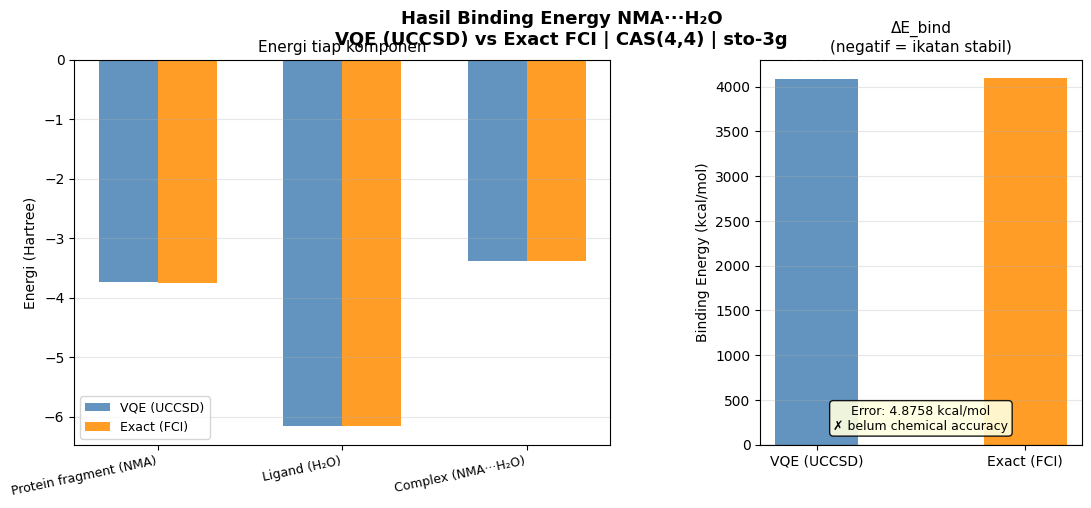

Gambar disimpan: uccsd_binding_energy.png


In [13]:
fig = plt.figure(figsize=(13, 5))
fig.suptitle(
    f'Hasil Binding Energy NMA···H₂O\n'
    f'VQE (UCCSD) vs Exact FCI | CAS({N_ELECTRONS},{N_ORBITALS}) | {BASIS_SET}',
    fontsize=13, fontweight='bold'
)
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[2, 1.2], wspace=0.35)

# Panel kiri: energi komponen
ax1   = fig.add_subplot(gs[0])
labels = [results[m]['label'] for m in MOL_LIST]
e_vqe  = [results[m]['vqe']   for m in MOL_LIST]
e_exact= [results[m]['exact'] for m in MOL_LIST]

x = np.arange(len(labels))
w = 0.32
bars1 = ax1.bar(x - w/2, e_vqe, w, label='VQE (UCCSD)', color='steelblue', alpha=0.85)
if all(e is not None for e in e_exact):
    ax1.bar(x + w/2, e_exact, w, label='Exact (FCI)', color='darkorange', alpha=0.85)

ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=9, rotation=12, ha='right')
ax1.set_ylabel('Energi (Hartree)', fontsize=10)
ax1.set_title('Energi tiap komponen', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() - 0.02,
             f'{bar.get_height():.4f}',
             ha='center', va='top', fontsize=8, color='white', fontweight='bold')

# Panel kanan: ΔE binding
ax2     = fig.add_subplot(gs[1])
b       = results['binding']
be_vals = [b['vqe_kcal']]
be_lbls = ['VQE (UCCSD)']
be_cols = ['steelblue']

if b['exact_kcal'] is not None:
    be_vals.append(b['exact_kcal'])
    be_lbls.append('Exact (FCI)')
    be_cols.append('darkorange')

bars = ax2.bar(be_lbls, be_vals, color=be_cols, alpha=0.85, width=0.4)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('Binding Energy (kcal/mol)', fontsize=10)
ax2.set_title('ΔE_bind\n(negatif = ikatan stabil)', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, be_vals):
    va = 'top' if val < 0 else 'bottom'
    yp = val - 0.05 if val < 0 else val + 0.05
    ax2.text(bar.get_x() + bar.get_width()/2, yp,
             f'{val:.3f}\nkcal/mol',
             ha='center', va=va, fontsize=10, fontweight='bold', color='white')

if b['exact_kcal'] is not None:
    err = abs(b['vqe_kcal'] - b['exact_kcal'])
    chk = '✓ chemical accuracy' if err < 1.0 else '✗ belum chemical accuracy'
    ax2.text(0.5, 0.04,
             f'Error: {err:.4f} kcal/mol\n{chk}',
             transform=ax2.transAxes, ha='center', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.savefig('uccsd_binding_energy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: uccsd_binding_energy.png')